
# **Did COVID-19 Change Crime Rates in Mexico?**  
### *A Step-by-Step Scientific Report (2019–2023)*

**Author:** Aneliya Lyavova 
**Date:** _2025-08-17_

---

## Abstract / Introduction

COVID-19 shaked the world in 2019 and affected almost every part of life: health, economy, education, politics, and even people’s mental health. Times of crisis often change how people behave. Conditions and situations such as stress, job loss, and uncertainty can sometimes lead to more crime (especially domestic violence), while strict lockdowns might reduce it (street theft during strict lockdowns).

And during 2020, Mexico was among the top 10 countries with the highest number of COVID-19 cases; It was also the country was among the top 5 countries with the highest number of deaths caused by this disease.

In this project, I will explore whether crime rates in Mexico changed during the pandemic years (2019–2023). By looking at official crime statistics alongside COVID-19 data, I want to see if there is a connection between the two.

**Goal.** This notebook investigates whether — and how — the COVID-19 pandemic influenced crime rates in Mexico between **2019–2023**, combining official Mexican crime statistics with COVID-19 indicators.

**Primary Hypothesis (H1).** The COVID-19 pandemic **significantly changed** crime rates in Mexico relative to pre-pandemic trends.

**Secondary Hypotheses (examples; keep the ones you’ll test):**
- **H1a.** Certain crimes (e.g., *domestic violence*) increased during the pandemic period.
- **H1b.** Certain crimes (e.g., *street robbery*) decreased during the most restrictive periods.
- **H1c.** COVID-19 intensity (cases/deaths per 100k) is positively associated with some crime categories after controlling for trends and seasonality.

**Null Hypothesis (H0).** There is **no significant change** in crime rates due to the pandemic beyond existing trends/seasonality.

> _You can edit/specialize the hypotheses after examining the data._

---


**Datasets provided by the Mexican Government and downloaded from Kaggle**
Links: 
- COVID-19 Dataset: https://www.kaggle.com/datasets/meirnizri/covid19-dataset/data
- Mexican Crime Statistics: Comprehensive (2015-2023): https://www.kaggle.com/datasets/elanderos/official-crime-stats-mexico-2015-2023
---

## Imports

In [1]:
%matplotlib inline

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Dataset Reading and quick view

> In the other two uploaded notebooks I have tidied and cleaned the data. For this reason, I will read the preprocessed versions now.


In [3]:
# Reading the covid dataset

# This whole procedures is absolutely necessary because when creating a new csv with the preprocessed version in the other notebook, dtypes are not saved in the new file.

with open("data/covid_data_dtypes.json", "r") as f:
    dtypes_dict = json.load(f)

# Identify datetime columns
datetime_cols = [col for col, dt in dtypes_dict.items() if dt.startswith('datetime')]

# Remove datetime columns from dtype dict
for col in datetime_cols:
    dtypes_dict.pop(col)

covid_data = pd.read_csv(
    "data/covid_data_preprocessed.csv",
    dtype=dtypes_dict,
    parse_dates=datetime_cols
)


In [4]:
# Reading the crime dataset

# This whole procedures is absolutely necessary because when creating a new csv with the preprocessed version in the other notebook, dtypes are not saved in the new file.

with open("data/crime_data_dtypes.json", "r") as f:
    dtypes_dict = json.load(f)

# Identify datetime columns
datetime_cols = [col for col, dt in dtypes_dict.items() if dt.startswith('datetime')]

# Remove datetime columns from dtype dict
for col in datetime_cols:
    dtypes_dict.pop(col)

crime_data = pd.read_csv(
    "data/crime_data_preprocessed.csv",
    dtype=dtypes_dict,
    parse_dates=datetime_cols
)


In [5]:
# Size of the COVID dataset
covid_data.shape

(391979, 21)

In [6]:
# Size of the Crime dataset
crime_data.shape

(332416, 9)

In [7]:
pd.set_option('display.max_columns', 21)

In [8]:
covid_data.head()

,sex,age,classification_final,patient_type,icu,intubed,pneumonia,pregnant,diabetes,copd,asthma,inmsupr,hypertension,cardiovascular,renal_chronic,other_disease,obesity,tobacco,usmer,medical_unit,date_died
0,f,65,Mild COVID,Sent home,Unknown,Unknown,Yes,No,No,No,No,No,Yes,No,No,No,No,No,No,1,2020-03-05
1,m,55,Mild COVID,Hospitalized,No,Yes,No,Unknown,Yes,No,No,No,No,No,No,No,No,No,No,1,2020-09-06
2,m,68,Mild COVID,Sent home,Unknown,Unknown,No,Unknown,Yes,No,No,No,Yes,No,No,No,No,No,No,1,2020-06-21
3,f,40,Mild COVID,Hospitalized,No,No,Yes,No,No,No,No,No,No,No,No,No,No,No,No,1,NaT
4,f,64,Mild COVID,Sent home,Unknown,Unknown,No,No,No,No,No,No,No,No,No,No,No,No,No,1,NaT


In [9]:
crime_data.sample(5)

,year,entity_code,entity,affected_legal_good,type_of_crime,subtype_of_crime,modality,month,crime_cases_count
122681,2018,4,Campeche,The family,Non-compliance with family support obligations,Non-compliance with family assistance obligations,Non-compliance with family assistance obligations,May,0
32571,2016,13,Hidalgo,Sexual freedom and security,Simple rape,Simple Rape,Simple rape,February,44
121675,2017,26,Sonora,Heritage or property,Robbery,Public Transportation Robbery,With violence,May,0
202485,2016,19,Nuevo León,Life and bodily integrity,Injuries,Unintentional Injury,Not specified,August,0
229650,2016,8,Chihuahua,Sexual freedom and security,Aggravated rape,Equivalent Rape,Equivalent rape,September,21


### Features

**COVID DATASET**

- sex: 'f' for female and 'm' for male. (type: category)
- age: of the patient. (type: int)
- classification_final: covid test findings. Values 1-3 mean that the patient was diagnosed with covid in different
degrees (type: category)
- patient type: type of care the patient received in the unit. Values: "Sent home" and "Hospitalized".
- pneumonia: whether the patient already have air sacs inflammation or not.
- pregnancy: whether the patient is pregnant or not.
- diabetes: whether the patient has diabetes or not.
- -copd: Indicates whether the patient has Chronic obstructive pulmonary disease or not.
- asthma: whether the patient has asthma or not.
- inmsupr: whether the patient is immunosuppressed or not.
- hypertension: whether the patient has hypertension or not.
- cardiovascular: whether the patient has heart or blood vessels related disease.
- renal chronic: whether the patient has chronic renal disease or not.
- other disease: whether the patient has other disease or not.
- obesity: whether the patient is obese or not.
- tobacco: whether the patient is a tobacco user.
- usmr: Indicates whether the patient treated medical units of the first, second or third level.
- medical unit: type of institution of the National Health System that provided the care.
- intubed: whether the patient was connected to the ventilator.
- icu: Indicates whether the patient had been admitted to an Intensive Care Unit.
- date died: If the patient died indicate the date of death, and 9999-99-99 otherwise.

**CRIME DATASET**
year: The year when the crime was reported. This is a numeric field representing the calendar year (e.g., 2015).

entity_code: A numeric code representing a specific entity (state or region) within Mexico. Each number corresponds to a unique entity.

entity: The name of the Mexican state or region where the crime occurred. This is a textual field (e.g., Aguascalientes).

affected_legal_good: A categorical field describing the broad category of the legal good (i.e., personal or societal interest) affected by the crime. Examples include 'Personal freedom' and 'Sexual freedom and security'.

type_of_crime: A categorical field indicating the general type of crime. This field is more specific than 'affected_legal_good' but less specific than 'subtype_of_crime'. Examples include 'Abduction', 'Sexual abuse', and 'Robbery'.

subtype_of_crime: A further categorization of the type of crime. This field provides more specific details within the general type of crime. Examples include 'Sexual Harassment', 'Simple Rape', and 'Home Burglary'.

modality: The specific nature or method of the crime. This field details how the crime was committed or any specific characteristic that differentiates it within its subtype. Examples include 'With violence', 'Without violence', 'Sexual Bullying'.

month: The month when the crime was reported. This is a textual field representing the month (e.g., January).

count: The number of reported incidents for the specific crime type, subtype, and modality in the given entity and month. This is a numeric field

## Useful Methods

In [10]:
def plot_heatmap(data, title, x_label, y_label, ax = None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 6))
    
    sns.heatmap(
        data, 
        annot=True,         
        fmt='d',              
        cmap='YlOrRd',         
        linewidths=0.5,
        ax=ax
    )
    ax.set_title(title)
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)

In [11]:
def create_month_t_plot(data, title, x_label, y_label):
    data.T.plot(
        kind='line', 
        marker='o', 
        figsize=(10, 6), 
        colormap='tab10'
    )
    plt.title(title)
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.grid(True)
    plt.show()


## Observation

## Hypotheses

### H1: During 2020–2021, months with higher COVID-19 mortality are associated with lower reported crime counts in Mexico, compared to pre-pandemic and post-pandemic trends.

In [12]:
# I create a new column in covid_data so that I can use the months easier now and later on
covid_data["month_died"] = covid_data[covid_data["date_died"].notna()]["date_died"].dt.month.astype("Int64")

# Doing the same for the years
covid_data["year_died"] = covid_data[covid_data["date_died"].notna()]["date_died"].dt.year

In [13]:
monthly_summary = covid_data["month_died"].value_counts(dropna = False, normalize = True)
monthly_summary

month_died
<NA>    0.861635
6        0.03414
5        0.02882
7       0.025124
4       0.013136
8       0.005151
12      0.004847
9       0.004635
10      0.004602
11      0.004597
3       0.004577
1       0.004503
2       0.004232
Name: proportion, dtype: Float64

Fortunately, 86% or the people sick with COVID are alive.

In [14]:
# I create a pivot table to see how many death cases there are for each month of each year.
pivot = covid_data.pivot_table(
    index = 'year_died',     
    columns = 'month_died',    
    values = 'date_died',      
    aggfunc = 'count',          
    fill_value = 0           
)

In [15]:
pivot

month_died,1,2,3,4,5,6,7,8,9,10,11,12
year_died,,,,,,,,,,,,
2020.0,1729,1639,1761,5080,11295,13378,9845,2016,1815,1801,1800,1896
2021.0,36,20,33,69,2,4,3,3,2,3,2,4


In [16]:
plot_heatmap(pivot, "Monthly COVID Deaths per Year", "Month", "Year")
print()

As I can see, in 2020 are reported much more death cases caused by COVID-19.

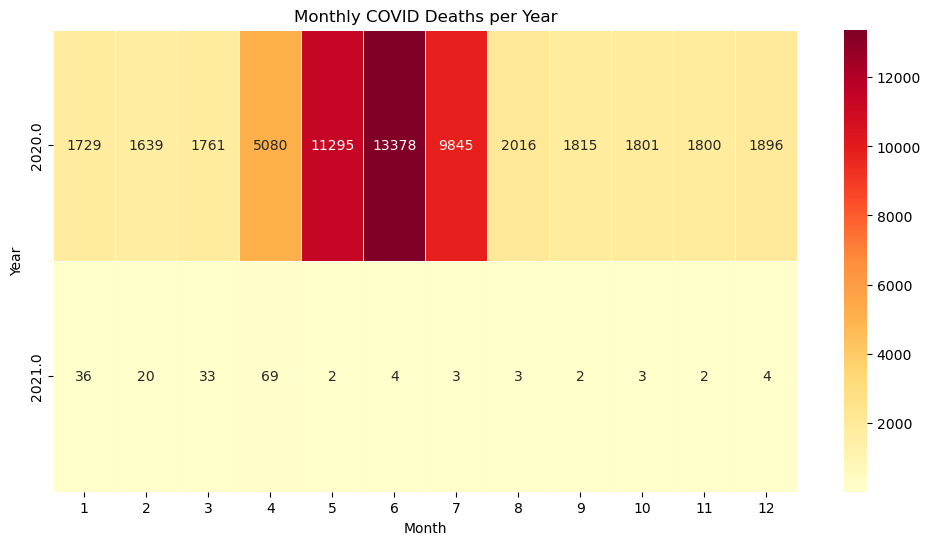

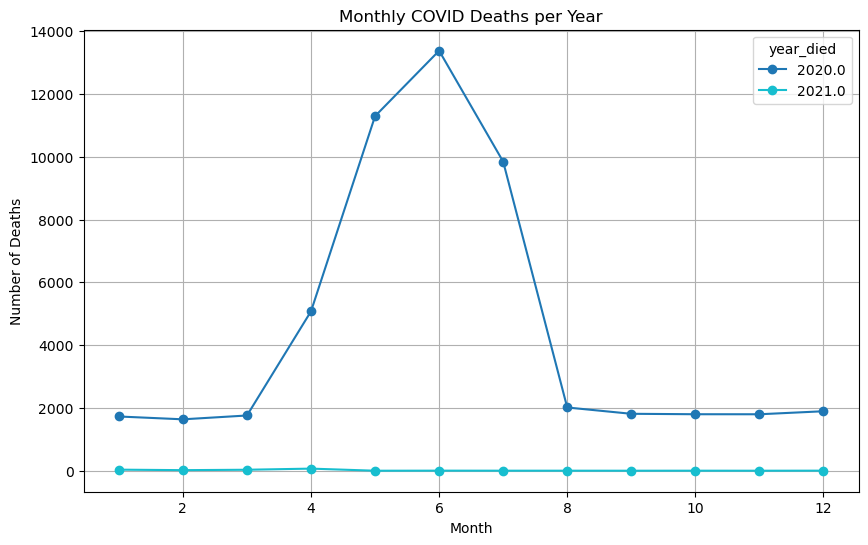

In [17]:
create_month_t_plot(pivot, "Monthly COVID Deaths per Year", "Month", "Number of Deaths")

The distribution of COVID deaths in 2020 roughly resembles a normal distribution, with a peak in the summer months, although it is slightly skewed.
The distribution of COVID deaths in 2021 is almost linear with a line parallel to the x-axis.

In [18]:
crimes_during_covid = crime_data[(crime_data.year == 2020) | (crime_data.year == 2021)][["year", "month", "crime_cases_count"]]
# Converting the months to their number in the year
crimes_during_covid["month"] = pd.to_datetime(crimes_during_covid["month"], format="%B").dt.month
crimes_during_covid

,year,month,crime_cases_count
15680,2020,1,3
15681,2020,1,0
15682,2020,1,1
15683,2020,1,0
15684,2020,1,0
...,...,...,...
329275,2021,12,8
329276,2021,12,1
329277,2021,12,20
329278,2021,12,8


In [19]:
crimes_during_covid_pivot = crimes_during_covid.pivot_table(index = "year", columns = "month", values = "crime_cases_count", aggfunc = "sum")
crimes_during_covid_pivot = crimes_during_covid_pivot.sort_index(axis=1)
crimes_during_covid_pivot

month,1,2,3,4,5,6,7,8,9,10,11,12
year,,,,,,,,,,,,
2020,165812,167607,171388,119807,121863,141771,154103,158209,161124,170863,155116,153528
2021,147612,150734,183122,174454,178081,176220,169967,171832,170668,178010,171073,172483


In [20]:
plot_heatmap(crimes_during_covid_pivot, "Monthly Crimes Count per Year", "Month", "Year")
print()

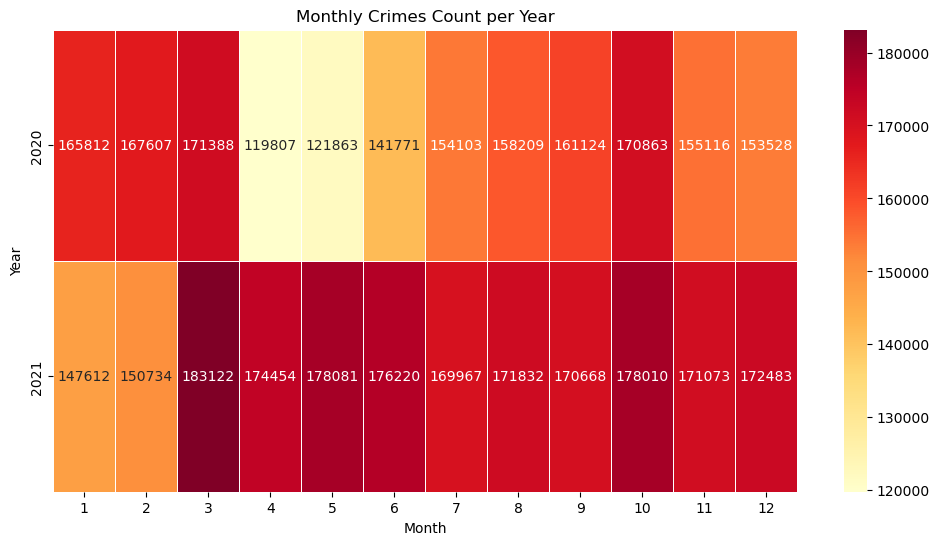

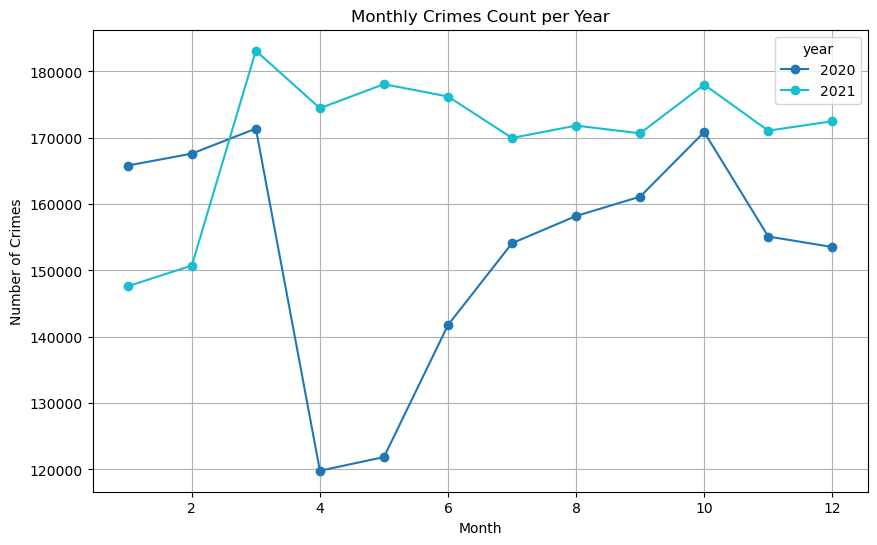

In [21]:
create_month_t_plot(crimes_during_covid_pivot, "Monthly Crimes Count per Year", "Month", "Number of Crimes")

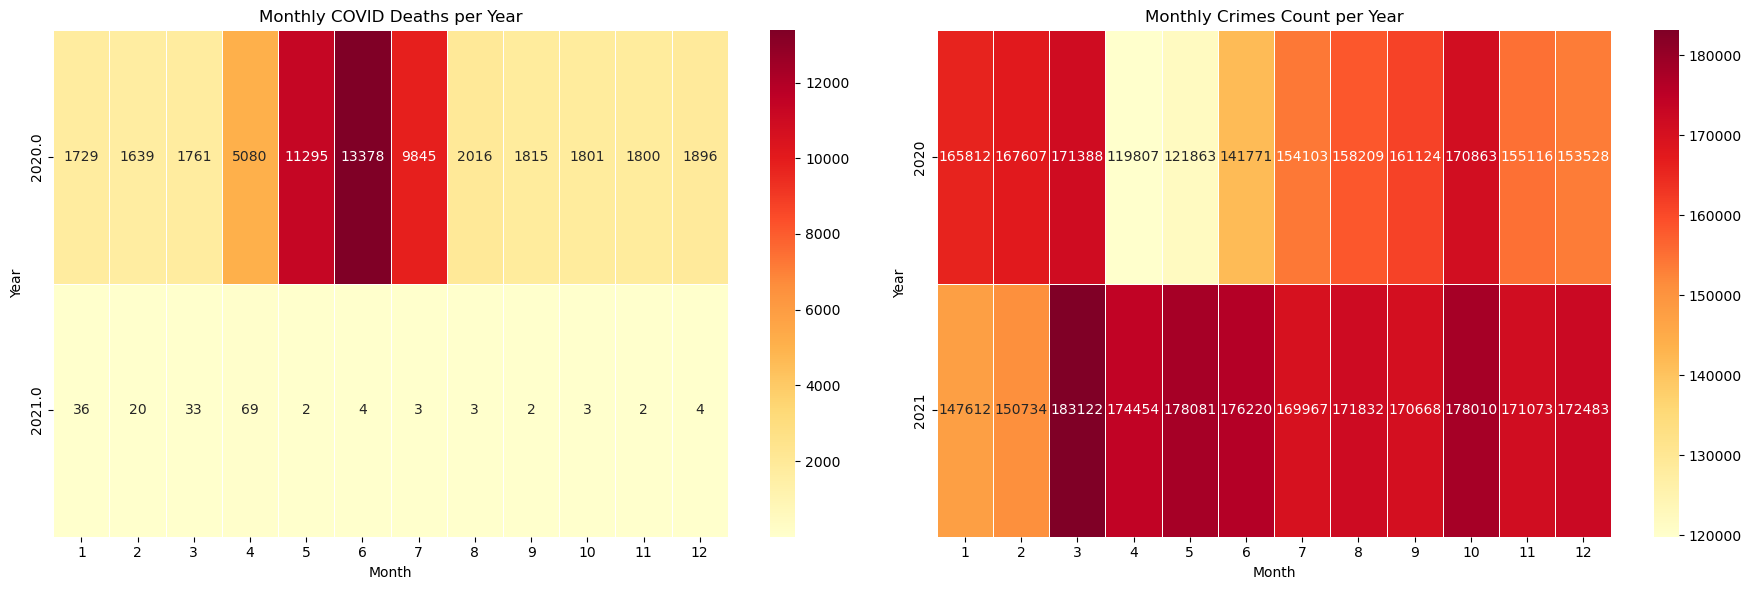

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

plot_heatmap(pivot, "Monthly COVID Deaths per Year", "Month", "Year", ax=axes[0])
plot_heatmap(crimes_during_covid_pivot, "Monthly Crimes Count per Year", "Month", "Year", ax=axes[1])

plt.tight_layout()
plt.show()

**I spot something interesting here: 
- 2020: Crime count dropped sharply in April (~119k) — exactly when COVID deaths started rising. Before and after, counts were higher (167k in January vs 170k in September). 
- 2021: Suggests a rebound after the 2020 lockdown dip - when the cases of COVID deaths are at their low, crime cases jump to the highest across all months (~170k–180k) and in the end of the year when death cases are no more than 4. Nevertheless, it is interesting that death cases in 2021 are so low. I suppose that data for 2021 is not full but it is difficult to believe that the Mexican government will skip recording such important things.**

This matches the expectation: mobility restrictions in early pandemic → **crime drop, then recovery**.
**However, let's prove this with some tests.**

## Refined Hypothesis: H1*: During 2020, months with higher COVID-19 mortality are associated with lower reported crime counts in Mexico, compared to pre-pandemic and post-pandemic trends.

A fast check to see if I have done a mistake with filtering because the cases for 2021 are really little for such a bug country.

In [23]:
covid_data["year_died"].value_counts(dropna = False)

year_died
NaN       337743
2020.0     54055
2021.0       181
Name: count, dtype: int64

In [24]:
covid_data["year_died"].value_counts(dropna = False, normalize = True)

year_died
NaN       0.861635
2020.0    0.137903
2021.0    0.000462
Name: proportion, dtype: float64

In [25]:
deaths_per_year = covid_data["date_died"].notna().sum()
print(deaths_per_year)


54236


Filtering looks fine, but the dataset is incomplete. About 86% of the year_died values are NaN, which indicates that most COVID-infected individuals are recorded as alive. The reported deaths for 2021 are extremely low — only 181 cases — whereas official sources (e.g., Johns Hopkins Coronavirus Resource Center) report 857 deaths on February 19th alone.
To avoid drawing misleading conclusions, I will exclude 2021 from the analysis and focus only on 2020, which has reliable and complete data.

In [26]:
# I take only the months from 2020 in which death cases were reported
covid_2020 = covid_data[(covid_data["year_died"] == 2020) & (covid_data["month_died"].notna())]

covid_monthly = (
    covid_2020
    .groupby("month_died")
    .size()                #
    .reset_index(name="deaths")
    .rename(columns = {"month_died" : "month"})
)

covid_monthly.index = covid_monthly.index.astype(int)

print(covid_monthly)


    month  deaths
0       1    1729
1       2    1639
2       3    1761
3       4    5080
4       5   11295
5       6   13378
6       7    9845
7       8    2016
8       9    1815
9      10    1801
10     11    1800
11     12    1896


In [32]:
# Taking the crime cases from 2020
crime_2020 = crime_data[crime_data.year == 2020][["month", "crime_cases_count"]]
# Converting the months to their number in the year
crime_2020["month"] = pd.to_datetime(crime_2020["month"], format="%B").dt.month
crime_2020

,month,crime_cases_count
15680,1,3
15681,1,0
15682,1,1
15683,1,0
15684,1,0
...,...,...
326139,12,5
326140,12,0
326141,12,20
326142,12,0


In [33]:
crime_monthly = crime_2020.groupby("month").sum().reset_index()

crime_monthly = crime_monthly.sort_values(by = "month", ascending = True)
print(crime_monthly)


    month  crime_cases_count
0       1             165812
1       2             167607
2       3             171388
3       4             119807
4       5             121863
5       6             141771
6       7             154103
7       8             158209
8       9             161124
9      10             170863
10     11             155116
11     12             153528


In [42]:
merged = pd.merge(covid_monthly, crime_monthly, on="month", how="inner")


# Sort by month 
# merged = merged.sort_values(by = "month").reset_index(drop=True)
print(merged)

    month  deaths  crime_cases_count
0       1    1729             165812
1       2    1639             167607
2       3    1761             171388
3       4    5080             119807
4       5   11295             121863
5       6   13378             141771
6       7    9845             154103
7       8    2016             158209
8       9    1815             161124
9      10    1801             170863
10     11    1800             155116
11     12    1896             153528


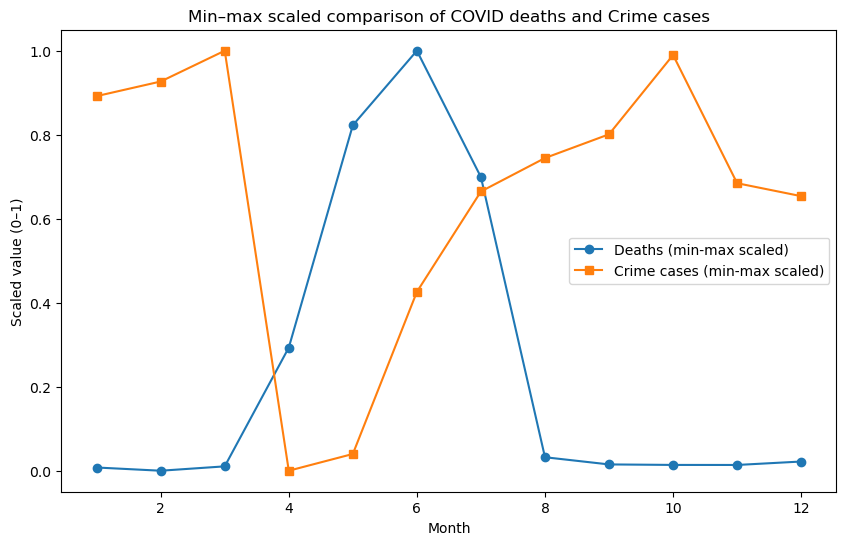

In [35]:
# I do a min-max normalization so that covid deaths count and crime cases count can be put on the same axis

covid_monthly_norm = covid_monthly.copy()
crime_monthly_norm = crime_monthly.copy()

# Min-max normalization for deaths
covid_monthly_norm["deaths_norm"] = (
    (covid_monthly["deaths"] - covid_monthly["deaths"].min()) 
    / (covid_monthly["deaths"].max() - covid_monthly["deaths"].min())
)

# Min-max normalization for crime cases
crime_monthly_norm["crime_norm"] = (
    (crime_monthly["crime_cases_count"] - crime_monthly["crime_cases_count"].min()) 
    / (crime_monthly["crime_cases_count"].max() - crime_monthly["crime_cases_count"].min())
)

# Plot
plt.figure(figsize=(10,6))
plt.plot(covid_monthly_norm["month"], covid_monthly_norm["deaths_norm"], marker="o", label="Deaths (min-max scaled)")
plt.plot(crime_monthly_norm["month"], crime_monthly_norm["crime_norm"], marker="s", label="Crime cases (min-max scaled)")

plt.xlabel("Month")
plt.ylabel("Scaled value (0–1)")
plt.title("Min–max scaled comparison of COVID deaths and Crime cases")
plt.legend()
plt.show()


What can be noticed from this chart is that when COVID deaths started increasing, cases of crime instantly dropped down - from the sky to the earth literally. 
This may be due to the fear which people got when they were listening to the bad statistics telling that more and more people were dying from this subtle disease.
Futhermore, lockdowns also pay their role because the more the deaths - the worser the situation becomes which leads to stricter health measures.
From the graphs it can also be seen that when death cases go to the bottom, crime goes up again. Later on, I will compare the pre-pandemic and post-pandemic periods.

### Support of the hypothesis

#### Pearson and Spearman Correlation Tests

In [43]:
from scipy.stats import pearsonr, spearmanr

# Pearson correlation (linear)
pearson_corr, pearson_p = pearsonr(merged["deaths"], merged["crime_cases_count"])
print(f"Pearson correlation: {pearson_corr:.3f}, p-value={pearson_p:.4f}")

# Spearman correlation (rank-based, non-linear)
spearman_corr, spearman_p = spearmanr(merged["deaths"], merged["crime_cases_count"])
print(f"Spearman correlation: {spearman_corr:.3f}, p-value={spearman_p:.4f}")

Pearson correlation: -0.646, p-value=0.0234
Spearman correlation: -0.804, p-value=0.0016


What both tests show is two negative coefficients which support the hypothesis: more deaths, fewer crime cases.
- Pearson measures linear relationship: moderate negative correlation.
- Spearman measures monotonic relationship: stronger negative association, meaning even if not perfectly linear, higher deaths generally correspond to lower crime counts.
- Moreover, the p-value from both tests in < 0.05, which means that this is a statistically significant relationship. P-values indicate that these negative correlations are unlikely due to random chance.

#### Simple Linear Regression Model

In [44]:
import statsmodels.api as sm

# Independent variable (COVID deaths)
X = merged["deaths"]
X = sm.add_constant(X)  # adds intercept

# Dependent variable (crimes)
y = merged["crime_cases_count"]

# Fit regression model
model = sm.OLS(y, X).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:      crime_cases_count   R-squared:                       0.417
Model:                            OLS   Adj. R-squared:                  0.358
Method:                 Least Squares   F-statistic:                     7.147
Date:                Wed, 20 Aug 2025   Prob (F-statistic):             0.0234
Time:                        23:49:58   Log-Likelihood:                -130.44
No. Observations:                  12   AIC:                             264.9
Df Residuals:                      10   BIC:                             265.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        1.65e+05   5895.844     27.978      0.0

C:\Users\aneli\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=12 observations were given.
  return hypotest_fun_in(*args, **kwds)


The result: 
- Independent variable: Monthly COVID deaths (2020) 
- Dependent variable:  Monthly crime cases (2020)
- The R-squared characteristics shows that approx. 42% of the variation of crime counts is explained by COVID deaths.
- The coefficient for deaths = - 2.5583 (p = 0.023) which means that for each additional 1 COVID death, there are ~2.6 fewer reported crimes, on average.
Also, that coefficient is negative and statistically significant (p < 0.05) which shows the inverse proportionality between deaths and crime and this **supports my hypothesis**.
- Constant (intercept) = 165,000 → When deaths = 0, the model predicts ~165,000 crimes in a month.
(Makes sense, since January 2020 had very low deaths and crime was ~165k).

Conclusion: This linear regression model showed that higher COVID-19 mortality was significantly associated with lower crime reports.


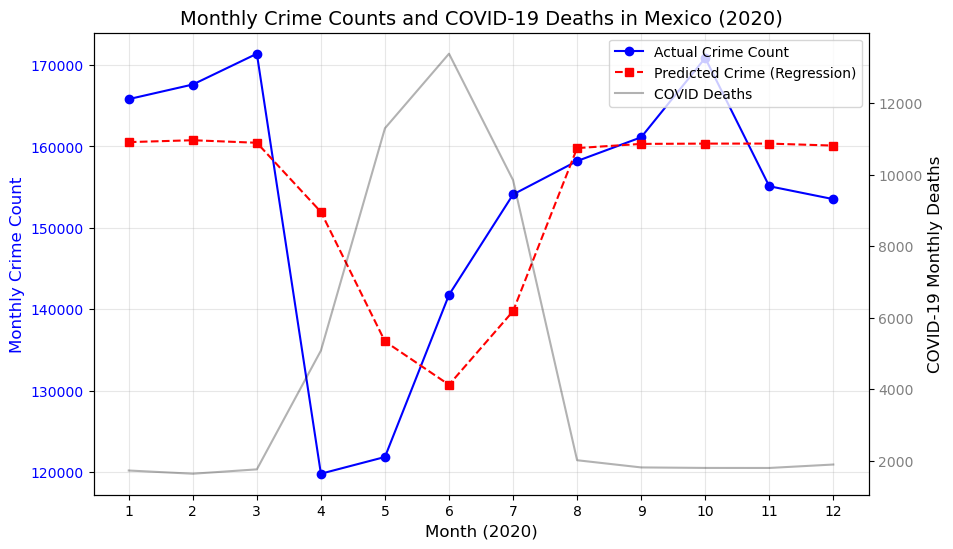

In [57]:
fig, ax1 = plt.subplots(figsize=(10,6))

# Plot actual and predicted crime counts (left axis)
ax1.plot(merged["month"], merged["crime_cases_count"], marker="o", label="Actual Crime Count", color="blue")
ax1.plot(merged["month"], merged["predicted_crime"], marker="s", linestyle="--", color="red", label="Predicted Crime (Regression)")

ax1.set_xlabel("Month (2020)", fontsize=12)
ax1.set_ylabel("Monthly Crime Count", fontsize=12, color="blue")
ax1.tick_params(axis='y', labelcolor="blue")
ax1.set_xticks(merged["month"])
ax1.grid(alpha=0.3)

# Second y-axis for COVID deaths
ax2 = ax1.twinx()
ax2.plot(merged["month"], merged["deaths"], alpha=0.3, color="black", label="COVID Deaths")
ax2.set_ylabel("COVID-19 Monthly Deaths", fontsize=12, color="black")
ax2.tick_params(axis='y', labelcolor="gray")

# Legends
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc="upper right")

plt.title("Monthly Crime Counts and COVID-19 Deaths in Mexico (2020)", fontsize=14)
plt.show()


Interestingly, the regression line appears to mirror the "COVID Deaths" curve, suggesting a symmetry along the x-axis. Moreover, the model’s predictions closely match the observed crime counts, further supporting this observation.

#### Pre-pandemic and Post-Pandemic Crime Cases

Now let's check crime cases before 2020. 

In [71]:
crime_before_covid = crime_data[crime_data.year <= 2020]

In [72]:
# I will create a pivot table showing the number of cases in the period [2015 - 2020]
crime_before_covid_pivot = crime_before_covid.pivot_table(index = "year", values = "crime_cases_count", aggfunc = "sum")
crime_before_covid_pivot

,crime_cases_count
year,
2015,1657804
2016,1764179
2017,1939497
2018,1989935
2019,2071179
2020,1841191


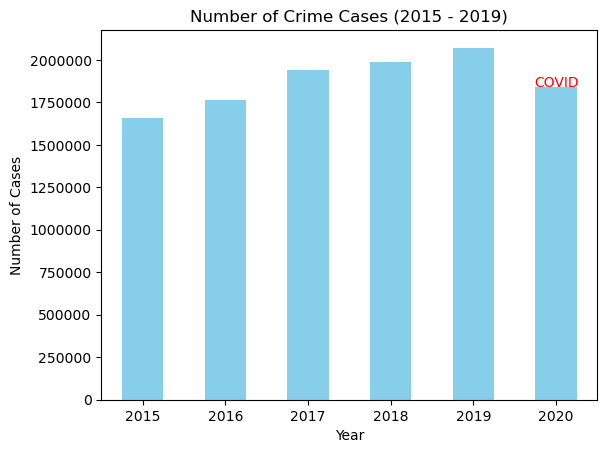

In [100]:
colors = ['skyblue'] * (len(crime_before_covid_pivot) - 1) + ['red']

ax = crime_before_covid_pivot.plot(kind='bar', color=colors, legend=False)

plt.title("Number of Crime Cases (2015 - 2019)")
plt.xlabel("Year")
plt.ylabel("Number of Cases")
plt.xticks(rotation=0)
plt.ticklabel_format(style='plain', axis='y') 

last_year_index = len(crime_before_covid_pivot) - 1
last_bar_height = crime_before_covid_pivot.iloc[-1, 0]
ax.text(last_year_index, last_bar_height + 50, 'COVID', ha='center', color='red')

plt.show()


The change in crime cases is also obvious from this bar chart. When COVID started getting worse, crime cases dropped significantly in 2020 while they were at the their peak in the previous year - 2019.

Selected ARIMA order: (1, 1, 2) with AIC=101.63


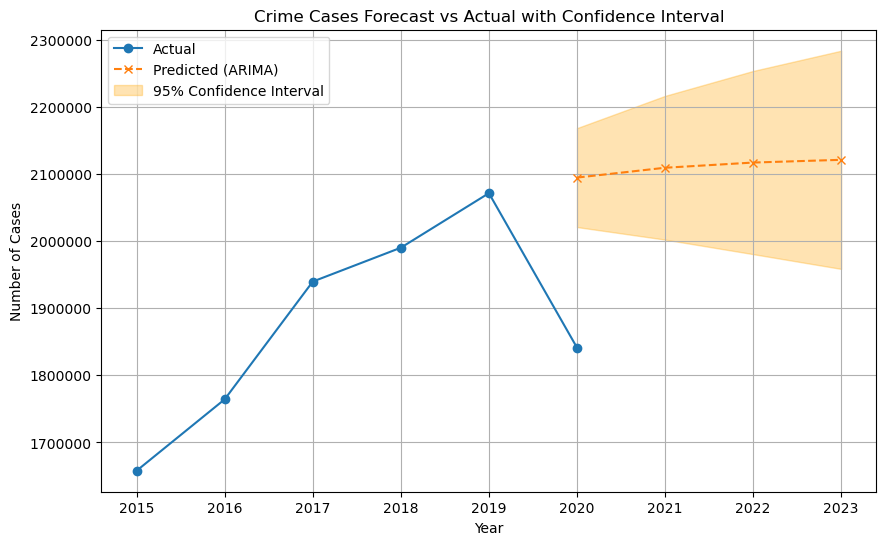

In [96]:
# Required libraries

from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings("ignore")

train = crime_before_covid_pivot.loc[2015:2019]['crime_cases_count']
test = crime_after_covid_pivot.loc[2020:]['crime_cases_count']  

# Automatic ARIMA parameter selection (grid search)
best_aic = float("inf")
best_order = None

for p in range(0, 3):  # try p=0,1,2
    for d in range(0, 2):  # try d=0,1
        for q in range(0, 3):  # try q=0,1,2
            try:
                model = ARIMA(train, order=(p,d,q))
                model_fit = model.fit()
                if model_fit.aic < best_aic:
                    best_aic = model_fit.aic
                    best_order = (p,d,q)
            except:
                continue

print(f"Selected ARIMA order: {best_order} with AIC={best_aic:.2f}")

# Fit ARIMA with the best order
model = ARIMA(train, order=best_order)
model_fit = model.fit()

# Forecast for future years (2020–2023) with confidence intervals
forecast_years = [2020, 2021, 2022, 2023]
forecast_result = model_fit.get_forecast(steps=len(forecast_years))
forecast = forecast_result.predicted_mean
conf_int = forecast_result.conf_int(alpha=0.05)  # 95% confidence interval

forecast = pd.Series(forecast.values, index=forecast_years, name="forecast")
conf_int.index = forecast_years

all_data = pd.concat([crime_before_covid_pivot['crime_cases_count'], forecast], axis=1)

# Визуализация
plt.figure(figsize=(10,6))
plt.plot(all_data.index, all_data['crime_cases_count'], marker='o', label='Actual')
plt.plot(all_data.index, all_data['forecast'], marker='x', linestyle='--', label='Predicted (ARIMA)')
plt.fill_between(forecast_years, conf_int.iloc[:,0], conf_int.iloc[:,1],
                 color='orange', alpha=0.3, label='95% Confidence Interval')
plt.title('Crime Cases Forecast vs Actual with Confidence Interval')
plt.ticklabel_format(style='plain', axis='y') 
plt.xlabel('Year')
plt.ylabel('Number of Cases')
plt.legend()
plt.grid(True)
plt.show()

I used Arima which is a popular statistical model used for time series forecasting and it is, predicting future values based on past data.
ARIMA predicts about 2,100,000 crime cases in 2020. However, due to COVID, they are much fewer - 1,841,191.

This observation clearly shows that COVID has really affected criminal activity.  

In addition, let's see what happens in the period [2021-2023] in reality.

In [108]:
crime_after_covid = crime_data[crime_data.year >= 2020]
# I will create a pivot table showing the number of cases in the period [2021 - 2023]
crime_after_covid_pivot = crime_after_covid.pivot_table(index = "year", values = "crime_cases_count", aggfunc = "sum")
crime_after_covid_pivot


,crime_cases_count
year,
2020,1841191
2021,2044256
2022,2141979
2023,1839920


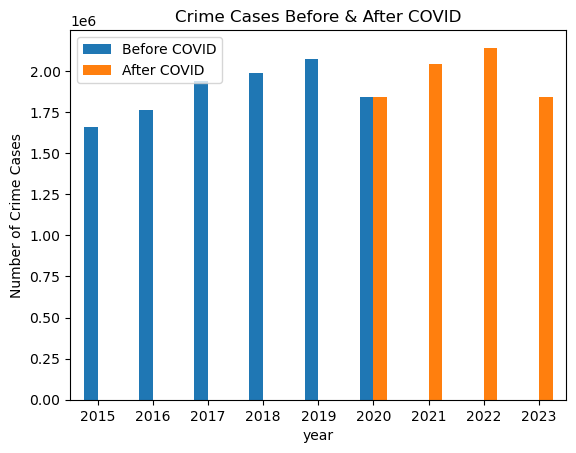

In [110]:
combined = pd.concat(
    [crime_before_covid_pivot.rename(columns={'crime_cases_count': 'Before COVID'}),
     crime_after_covid_pivot.rename(columns={'crime_cases_count': 'After COVID'})],
    axis=1
)

# Plot grouped bar chart
combined.plot(kind='bar', rot=0, title='Crime Cases Before & After COVID')
plt.ylabel('Number of Crime Cases')
plt.show()

After the heavy situation in 2020 criminal activity starts going up again when in 2020 it reaches their peak. In 2023 due to some reason, there is another dip.